# FRAUD DETECTION 

A classic problem in financial environments. We will take a look at classifying transitions into fraud and not fraud using scikit-learn package.

This notebook will be using a synthetic database found on kaggle for educational purposes because we all need practice :-).   
The data can be found here: https://www.kaggle.com/datasets/jayjoshi37/digital-payment-fraud-detection/data

I will break this process down into the follwoing steps:

1. Data Exploration 
2. Data prepartion and pre-processing (including feature engineering)
3. Modelling 
4. Evaluation and testing 

We have the following fields within our dataset: 

transaction_id - identifier to each transaction.   
user_id - identifier for each user.   
transaction_amount - amount for each transaction.   
transaction_type - how funds were exchanged e.g "payment" or "bank transfer".   
payment_mode - wallet, card, UPI etc.   
device_type - device transaction was made from e.g iOS.   
device_location - location of the device used to make transaction.   
account_age_days - age of the account.     
transaction_hour - time of transaction in 24 hour notation.    
previous_failed_attempts - if there were previous attempts to make fraudulent transactions.   
avg_transaction_amount - avg amount each account usually makes.   
is_international - is the trasnaction international.    
ip_risk_score - a numerical value  that quantifies the likelihood an IP address is involved in malicious activity, such as fraud, spam, or cyberattacks. 
login_attempts_last_24h - number of login attempts to the account in the last 24 hours.   
fraud_label- is the transaction fraud or not.


## Data Exploration 

In [90]:
# First we need to start by acquiring all of our dependecies 

# Basic dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Pipeline
from sklearn.pipeline import Pipeline                   # creating a data pre-propcessing pipeline for our test set 
from sklearn.preprocessing import FunctionTransformer   # to create feature engineering functions 
from sklearn.base import TransformerMixin, BaseEstimator # used to fit and transform data based on our class 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,balanced_accuracy_score, precision_recall_curve, confusion_matrix,precision_score, recall_score, ConfusionMatrixDisplay #importing all necesarry metrics


# Resampling 
from imblearn.over_sampling import SMOTE 
from imblearn.pipeline import Pipeline as Pipe

In [51]:
# Now we will load our data into our notebook for modelling:
current_dir = Path.cwd()
print(current_dir)              # this directory is 1 level too low in the project structure
parent_dir = current_dir.parent # go up 1 level in the structure 
print(parent_dir)               # now we are in the parent directory that we can now use to naviagte into the dataset 
file_path = parent_dir/ "dataset" / "train_data.csv" 
print(file_path)                # now we are in the correct bracnh of the tree where our dataset is

train = pd.read_csv(file_path)  # IT WORKED!!!


/Users/leta/Desktop/Data_Science_Career/Python/PythonProjects/FraudDetection/modelling
/Users/leta/Desktop/Data_Science_Career/Python/PythonProjects/FraudDetection
/Users/leta/Desktop/Data_Science_Career/Python/PythonProjects/FraudDetection/dataset/train_data.csv


In [52]:
train.keys()

Index(['user_id', 'transaction_amount', 'device_location', 'account_age_days',
       'transaction_hour', 'previous_failed_attempts', 'payment_mode',
       'device_type', 'transaction_type', 'avg_transaction_amount',
       'is_international', 'ip_risk_score', 'login_attempts_last_24h',
       'fraud'],
      dtype='str')

In [53]:
train['fraud'].value_counts(normalize=True)

fraud
0    0.934857
1    0.065143
Name: proportion, dtype: float64

In [54]:
# Now we will separte the dat into independent variables  x (e.g device location) and dependent variables y (fraud)

x = train[['user_id', 'transaction_amount', 'device_location', 'account_age_days',
       'transaction_hour', 'previous_failed_attempts', 'payment_mode',
       'device_type', 'transaction_type', 'avg_transaction_amount',
       'is_international', 'ip_risk_score', 'login_attempts_last_24h']]
y = train[['fraud']]

In [55]:
x.nunique()

user_id                     4004
transaction_amount          5250
device_location                5
account_age_days            1841
transaction_hour              24
previous_failed_attempts       5
payment_mode                   4
device_type                    3
transaction_type               3
avg_transaction_amount      5250
is_international               2
ip_risk_score                992
login_attempts_last_24h        9
dtype: int64

Our variables with categorical information being: transaction_type, payment_mode, device_type and device_location do not have too many unqiue values.  
This infroms what methods we can use to deal with these values for classification models that only use numerical data.  
- A possible solution would be to use dummy variables. 

##  DATA PREPARATION AND PRE-PROCESSING 


### PIPELINES & FEATURE ENGINEERING   
We will now create features that improve the performance of our models based on the EDA we conducted in R and the insights we gathered and then create a pipeline to automate the process. 
These are methods we can use to automate the data scince process by doing things like ETL, Pre-processing, Feature engineering and much more. 

We will create our own class to carry out transfromations on the train data d then fit our model to the test data.   
This will include the use of:   
 - FunctionTransformer
 - One hot encoding (replacing dummy variables in a previous iteration)
 - Standrad scaler so values like transaction amounts don't skew our model 

Let's get into it!!

In [ ]:
#Defining the class
class ETL(BaseEstimator, TransformerMixin): # scikit-learn's way of allowing us to do model training to find pattern and fitting those training weights and baises to data. 
    def __init__(self, alpha = 1): #alpha is used for smoothing our probability value to prevent unknown users from get a rarity of nan.
        self.alpha = alpha
        self.user_rarity_ = None       # user-level probabilities
        self.global_rarity_ = None     # global probabilities

    def fit(self, x , y = None):

        X = x.copy() 
        # Creating user level lookup table 
        # Let us start by  making an empty dataframe we will use to record the prevalnce of each User ID device location 
        users_location_history = pd.DataFrame({ #we have an empty list for each users location history of transactions 
            "user_id" :[],
            "Bangalore" :[], # probability that the user has transaction in Bangalore given thier past history (conditional). 
            "Chennai" :[],   # same as above 
            "Delhi" :[],
            "Hyderabad" :[],
            "Mumbai" :[],
        })   
        users_location_history["user_id"] = X["user_id"].unique()     # this makes an empty dataframe of all of the users we have in the training set 
     

        columns = users_location_history[['Bangalore','Chennai','Delhi','Hyderabad','Mumbai']] #columns where we want to assign zero to contents 
        col_array = np.array(columns)   #convert to array with nan entries 

        nan_array = np.isnan(col_array) # finding all cells that are NaN in col_array
        col_array[nan_array] = 0        # if a cell in array col_array is NaN assign 0
        users_location_history[['Bangalore','Chennai','Delhi','Hyderabad','Mumbai']] = col_array # now all the empty cells have been replaced with zeros          

        
        # Now we get the dummies for each location 
        location_dummies = pd.get_dummies(X, columns = ['device_location'], dtype = int)
        location_dummies = location_dummies[['user_id','device_location_Bangalore'	,                   # ensuring the dummy table is only the device locations and user IDs
                                            'device_location_Chennai',	'device_location_Delhi',	
                                            'device_location_Hyderabad'	,'device_location_Mumbai']]


        location_dummies = location_dummies.groupby(['user_id']).agg({'device_location_Bangalore': 'sum', # getting the sum of locations for each user's historical transactions
                                                                    'device_location_Chennai': 'sum',
                                                                    'device_location_Delhi': 'sum',
                                                                    'device_location_Hyderabad': 'sum',
                                                                    'device_location_Mumbai': 'sum'})

        # USER LEVEL RARITIES - for knonw user transaction histories 
        col_array_prob = np.array(location_dummies[['device_location_Bangalore','device_location_Chennai', # converting this into an array for faster computation
                                                    'device_location_Delhi','device_location_Hyderabad',	
                                                    'device_location_Mumbai']])

        num_features = location_dummies.shape[1]        # number of features in the array (5)
        total_per_user = col_array_prob.sum(axis = 1)   # sum of locations for each user (summation across rows)
        prob_array = (1- (col_array_prob + self.alpha)/(total_per_user[:, None]+ self.alpha * num_features)) #getting the rarity of a user having a transaction in a specific location (the higher the more rare the location for that user)
        users_location_history[['Bangalore','Chennai','Delhi','Hyderabad','Mumbai']] = prob_array # assigning this array to the dataframe 
        users_index = users_location_history.set_index("user_id") # new dataframe with user id as index
        stacked_users_location_history = users_index.stack()      # stacking the infromation from the cells of the dataframe 
        self.user_rarity_ = stacked_users_location_history.to_dict()    # string this data as a dictionary for later 


        #GLOBAL RARITIES - for any new users from the test set 
        total_in_data = col_array_prob.sum(axis=0) # total number of transactions in each location 
        total_across = col_array_prob.sum()        # total number of transactions
        total_prob_array = (1-(total_in_data + self.alpha)/ (total_across + self.alpha * num_features))   # rarities for each location in the training data to be applied to new users 
        city_names = ['Bangalore', 'Chennai', 'Delhi','Hyderabad','Mumbai']      # names of cities for lookups 
        self.global_rarity_ = dict(zip(city_names, total_prob_array))                           #saving these rarities as a dictionary  

        return self


    def transform( self, x):

        X = x.copy()

        user_ids = X["user_id"]
        locations = X["device_location"]

        x["location_rarity"] = [
            self.user_rarity_.get((u,l), self.global_rarity_.get(l,self.alpha))
            for u,l in zip(user_ids, locations)
        ]

        return x

    def drop_features(self, x):                           # drop features that we used to create our features like "user id"
        columns_to_drop = ['user_id','payment_mode', 'device_type', 'transaction_type', 'device_location']
        existing_columns = [ c for c in columns_to_drop if c in x.columns]
        x = x.drop(columns = existing_columns)
        return x

for reference these were some features I made before the ones you see. They were not predcitive at all and had very low balanced accruacy (50%),so it would classify everything as non fraud or high recall (90%) but low balaced accuracy and precision (6%) so it would classify everything as fraud.  This happened no matter the resampling or model used.

That just goes to  how the adage is true: "garbage in garbage out". Bad features go in, bad predictions come out. I'M SO PROUD OF MYSELF!!!

I'm just leaving this here to show my progress. If youre reading this follow me on github and chekc me out: https://github.com/leta199


def location_tag(x):
        #creating the location buckets 
        fraud_location = {  
        "Mumbai":5,     # highest likelihood of fraud 
        "Hyderabad" :4, # second highest likelihood of fraud etc
        "Chennai" : 3,
        "Bangalore" : 2,
        "Delhi" : 1}
        x["fraud_bucket_location"] = x["device_location"].map(fraud_location)
        return x #returning our processed test dataframe 
 
    def risk_buckets(x):
        #creating our risk buckets 
        x["ip_risk_bucket"] = np.where((x['ip_risk_score'] < 0.51) | 
                                        (x['ip_risk_score'] > 0.86), 1, 0)        # assign a 1 if the risk is in the dangerous category and 0 itherwise 

        #creating the account age buckets 
        x["account_age_bucket"] = np.where((x['account_age_days'] >= 1190 ) &
                                            (x['account_age_days'] <= 1855), 1,0) # assign a 1 if we have an account in the most denagrous range and 0 otherwise
        return x
    
    def amount_averages(x):
        transaction_average = pd.DataFrame()                        # empty dataframe to store averages 

        transaction_average["user_id"] = x['user_id'].unique()      # this represents each users average transaction amount for this round of transactions 

        means = x.groupby(['user_id'])['transaction_amount'].mean() # get the mean of each transaction amount from the test data for each User ID

        transaction_average["days_average"] = transaction_average["user_id"].map(means) # add this mean called "days_average" to the dataframe 

        averages_per_user = x.groupby(['user_id'])["avg_transaction_amount"].unique()   # conduct the same procedure for the historic known average of User IDs

        typical_average = averages_per_user.apply(np.mean)                              # get the mean of each average since some User IDs have multiple historic averages 

        transaction_average["typical_average"] = transaction_average["user_id"].map(typical_average) # add this updated historic average to the dataframe 
        x = x.merge(transaction_average, on = "user_id", how = 'left')                               # add this dataframe to x using joins and duplicate some for each User ID so left join
        return x
    
    def transaction_outliers(x):
        days_sd = np.std(x['days_average']) # standard deviation for the days average column (transaction amounts follow roughly uniform distribution form the EDA)

        outlier_days_avg = pd.DataFrame()   # empty dataframe to get the outlier transactions 

        outlier_days_avg["outlier_days_average"] = np.where( (x['transaction_amount'] <= x['days_average'] -  2.5* days_sd) | 
            (x['transaction_amount'] >= x['days_average'] + 2.5 * days_sd), 1,0)           #outliers on days average are transaction amounts outside 2.5 standard deviations from the mean
        
        typical_sd = np.std(x['typical_average']) # similar to the above 

        outlier_typical_avg = pd.DataFrame()
        outlier_typical_avg["outlier_typical_average"] = np.where( (x['transaction_amount'] <= x['days_average'] -  2.5* typical_sd) | 
            (x['transaction_amount'] >= x['days_average'] + 2.5 * typical_sd), 1,0)         # outliers outside 2 standard deviations from the mean are flagged with 1 otherwise 0
        
        x = pd.concat([x,outlier_days_avg,outlier_typical_avg ], axis =1)                   # adding the outliers in terms of the aveage amounts to the test dataframe x
        return x
    
    def international_outliers(x):
        commom_international = x.groupby('user_id')['is_international'].agg(lambda x: pd.Series.mode(x)[0]) # get the most common location (domestric or international) where each User does transactions from
        x['transaction_usual_international'] = x["user_id"].map(commom_international)                       # add this mode to the test dataframe
        x["unexpected_location"] = np.where((x['is_international'] == x['transaction_usual_international'] ) , 0,1) # assign 0 if the transaction is in the usual location and 1 otherwise
        return x

    def login_outliers(x):
        usual_login_attempts = x.groupby('user_id')['previous_failed_attempts'].mean()          # mean of the number of number of attempts to login by User ID 
        x['usual_login_attempts'] = x["user_id"].map(usual_login_attempts)                      # map these onto the test dataframe 
        x["unexpected_login_attempts"] = np.where((x['previous_failed_attempts'] <= x['usual_login_attempts'] ) , 0,1) #assign 0 is the transactions attempts are less than or equal to the normla amount and 1 otherwise 
        return x

In [72]:
#scaling and get dummies (one hot encoding our variables)
numeric_features = ['transaction_amount', 'account_age_days',
                     'transaction_hour', 'ip_risk_score', ] 
    
categorical_features = ['device_location', 'previous_failed_attempts',  'is_international', 'login_attempts_last_24h']

In [79]:



numeric_transformation = StandardScaler()
categorical_transformation = OneHotEncoder()

preprocess_data = ColumnTransformer(
    transformers= ([
        ("num" , numeric_transformation, numeric_features),
        ("cat", categorical_transformation,categorical_features)
    ]))

In [130]:
fit_transform = ETL()

pipeline = Pipeline([
    ("fit_transform", etl),
    ("preprocess", preprocess_data),
    ("Logistic_regression", LogisticRegression())
])

## MODELLING 

In [131]:
#We will now us the pipleine on our test data 
pipeline.fit(x, y)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('fit_transform', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,alpha,1
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [ ]:
#ADD FEATURES TO PRINT FIRST FEW ENGINEERED ROWS 

AttributeError: 'ETL' object has no attribute 'location_rarity_log'

## EVALUATION AND TESTING 
We have trained our model on the train set.   
We can now use the metrics mentined earlier like balanced accuracy, precision and recall to judge our models

**Precision** - of all the positievs identified how many were truly positive?  
**Recall**- of all possible positive instances, how many did the model catch? 

For fraud detection, we value recall as our main metric.   
This is beacuse catching every fraudlent trasaction allows for the least damage to our client base as opposed to flagging a genuine transaction as fraud that can be reversed wuth no harm to the user. 

In [132]:
current_dir = Path.cwd()
print(current_dir)              # this directory is 1 level too low in the project structure
parent_dir = current_dir.parent # go up 1 level in the structure 
print(parent_dir)               # now we are in the parent directory that we can now use to naviagte into the dataset 
file_path = parent_dir/ "dataset" / "test_data.csv" 
print(file_path)                # now we are in the correct bracnh of the tree where our dataset is

test = pd.read_csv(file_path) 

/Users/leta/Desktop/Data_Science_Career/Python/PythonProjects/FraudDetection/modelling
/Users/leta/Desktop/Data_Science_Career/Python/PythonProjects/FraudDetection
/Users/leta/Desktop/Data_Science_Career/Python/PythonProjects/FraudDetection/dataset/test_data.csv


In [133]:
test.keys()

Index(['user_id', 'transaction_amount', 'device_location', 'account_age_days',
       'transaction_hour', 'previous_failed_attempts', 'payment_mode',
       'device_type', 'transaction_type', 'avg_transaction_amount',
       'is_international', 'ip_risk_score', 'login_attempts_last_24h',
       'fraud'],
      dtype='str')

In [134]:
xt = test[['user_id', 'transaction_amount', 'device_location', 'account_age_days',
       'transaction_hour', 'previous_failed_attempts', 'payment_mode',
       'device_type', 'transaction_type', 'avg_transaction_amount',
       'is_international', 'ip_risk_score', 'login_attempts_last_24h', ]]
yt = test[['fraud']]

In [135]:
y_pred_log = pipeline.predict(xt) #making predictions on the train data 


In [136]:
accuracy_score(yt, y_pred_log) #we have a very high accuracy score of 0.935


0.9346666666666666

In [137]:
balanced_accuracy_score(yt,y_pred_log) #our balaned accuracy score is very lowe at 0.5

0.5

In [138]:
precision_score(yt,y_pred_log) # precision is 0%

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


0.0

In [139]:
recall_score(yt,y_pred_log) #recall is 0%

0.0

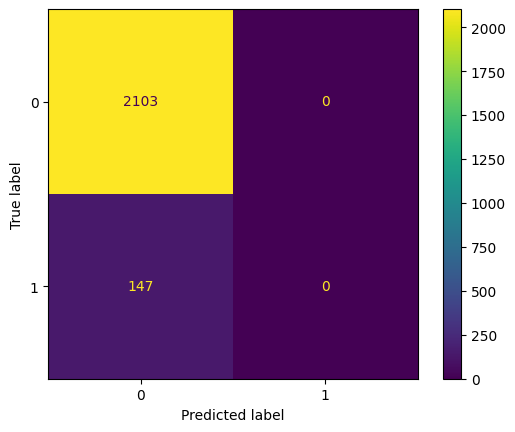

In [140]:
cm = confusion_matrix(yt, y_pred_log)
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()

In [141]:
fit_transform = ETL()

pipeline2 = Pipeline([
    ("fit_transform", etl),
    ("preprocess", preprocess_data),
    ("Logistic_regression", LogisticRegression(class_weight="balanced"))
])

In [142]:
#We will now us the pipleine on our test data 
pipeline2.fit(x, y)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('fit_transform', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,alpha,1
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [143]:
y_pred_log_2 = pipeline2.predict(xt) #making predictions on the train data 


In [144]:
accuracy_score(yt, y_pred_log_2) #we have a very high accuracy score of 0.935


0.5306666666666666

In [145]:
balanced_accuracy_score(yt,y_pred_log_2) #our balaned accuracy score is very lowe at 0.5

0.48635088842955154

In [146]:
precision_score(yt,y_pred_log_2) # precision is 0%

0.06171648987463838

In [147]:
recall_score(yt,y_pred_log_2) #recall is 0%

0.43537414965986393

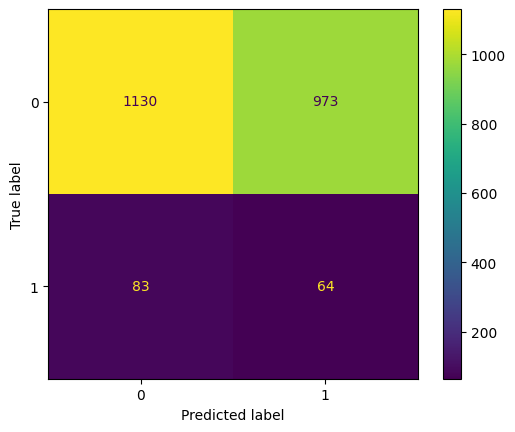

In [148]:
cm = confusion_matrix(yt, y_pred_log_2)
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()

In [ ]:
#Defining the class
class ETL2(BaseEstimator, TransformerMixin): # scikit-learn's way of allowing us to do model training to find pattern and fitting those training weights and baises to data. 
    def __init__(self, alpha = 1, cols = ["device_location","payment_mode"]): #alpha is used for smoothing our probability value to prevent unknown users from get a rarity of nan.
        self.alpha = alpha
        self.cols_ = cols
        self.user_rarity_ = {}      # user-level probabilities
        self.global_rarity_ = {}    # global probabilities

    def fit(self, x , y = None):

        X = x.copy() 
        # Creating user level lookup table 
        # Let us start by  making an empty dataframe we will use to record the prevalnce of each User ID device location 
        for col in self.cols_:
            dummies = pd.get_dummies(X[[col, "uder_id"]], columns= [col], dtype = int)
            colnames = [c.replace(f"{col}_", "") for c in dummies.columns if c != "uder_id"]
            dummies.columns = [c.replace(f"{col}_", "") if c != "uder_id" else c for c in dummies.columns]
            
        users_location_history = pd.DataFrame({ #we have an empty list for each users location history of transactions 
            "user_id" :[],
            "Bangalore" :[], # probability that the user has transaction in Bangalore given thier past history (conditional). 
            "Chennai" :[],   # same as above 
            "Delhi" :[],
            "Hyderabad" :[],
            "Mumbai" :[],
        })   
        users_location_history["user_id"] = X["user_id"].unique()     # this makes an empty dataframe of all of the users we have in the training set 
     

        columns = users_location_history[['Bangalore','Chennai','Delhi','Hyderabad','Mumbai']] #columns where we want to assign zero to contents 
        col_array = np.array(columns)   #convert to array with nan entries 

        nan_array = np.isnan(col_array) # finding all cells that are NaN in col_array
        col_array[nan_array] = 0        # if a cell in array col_array is NaN assign 0
        users_location_history[['Bangalore','Chennai','Delhi','Hyderabad','Mumbai']] = col_array # now all the empty cells have been replaced with zeros          

        
        # Now we get the dummies for each location 
        location_dummies = pd.get_dummies(X, columns = ['device_location'], dtype = int)
        location_dummies = location_dummies[['user_id','device_location_Bangalore'	,                   # ensuring the dummy table is only the device locations and user IDs
                                            'device_location_Chennai',	'device_location_Delhi',	
                                            'device_location_Hyderabad'	,'device_location_Mumbai']]


        location_dummies = location_dummies.groupby(['user_id']).agg({'device_location_Bangalore': 'sum', # getting the sum of locations for each user's historical transactions
                                                                    'device_location_Chennai': 'sum',
                                                                    'device_location_Delhi': 'sum',
                                                                    'device_location_Hyderabad': 'sum',
                                                                    'device_location_Mumbai': 'sum'})

        # USER LEVEL RARITIES - for knonw user transaction histories 
        col_array_prob = np.array(location_dummies[['device_location_Bangalore','device_location_Chennai', # converting this into an array for faster computation
                                                    'device_location_Delhi','device_location_Hyderabad',	
                                                    'device_location_Mumbai']])

        num_features = location_dummies.shape[1]        # number of features in the array (5)
        total_per_user = col_array_prob.sum(axis = 1)   # sum of locations for each user (summation across rows)
        prob_array = (1- (col_array_prob + self.alpha)/(total_per_user[:, None]+ self.alpha * num_features)) #getting the rarity of a user having a transaction in a specific location (the higher the more rare the location for that user)
        users_location_history[['Bangalore','Chennai','Delhi','Hyderabad','Mumbai']] = prob_array # assigning this array to the dataframe 
        users_index = users_location_history.set_index("user_id") # new dataframe with user id as index
        stacked_users_location_history = users_index.stack()      # stacking the infromation from the cells of the dataframe 
        self.user_rarity_ = stacked_users_location_history.to_dict()    # string this data as a dictionary for later 


        #GLOBAL RARITIES - for any new users from the test set 
        total_in_data = col_array_prob.sum(axis=0) # total number of transactions in each location 
        total_across = col_array_prob.sum()        # total number of transactions
        total_prob_array = (1-(total_in_data + self.alpha)/ (total_across + self.alpha * num_features))   # rarities for each location in the training data to be applied to new users 
        city_names = ['Bangalore', 'Chennai', 'Delhi','Hyderabad','Mumbai']      # names of cities for lookups 
        self.global_rarity_ = dict(zip(city_names, total_prob_array))                           #saving these rarities as a dictionary  

        return self


    def transform( self, x):

        X = x.copy()

        user_ids = X["user_id"]
        locations = X["device_location"]

        x["location_rarity"] = [
            self.user_rarity_.get((u,l), self.global_rarity_.get(l,self.alpha))
            for u,l in zip(user_ids, locations)
        ]

        return x

    def drop_features(self, x):                           # drop features that we used to create our features like "user id"
        columns_to_drop = ['user_id','payment_mode', 'device_type', 'transaction_type', 'device_location']
        existing_columns = [ c for c in columns_to_drop if c in x.columns]
        x = x.drop(columns = existing_columns)
        return x

### SMOTE 
Synthetic Minority Over-Sampling Technique (SMOTE)

SMOTE is a data-level resampling technique that generates synthetic (artificial) samples for the minority class.   
Instead of simply duplicating existing examples, it creates new data points by interpolating between existing ones.   
This approach allows the model to learn broader patterns and reduces the risk of overfitting to repeated samples

In [104]:
# Now we will resample our data 
# This will involve adding the resampling step midway through into our pipeline 




smt = SMOTE(sampling_strategy="minority", random_state= 40)

